In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("../data/Hospital_icu_data.xls")
df.head()

,Emergency Admissions,Scheduled Surgeries,Current Occupancy (%),Infection Index,Avg Stay (days),Average Monthly Patient Footfall,Ambulance Service Available,Count of Ambulance,Number of Beds in Emergency Wards,ICU Beds Required
0,23,6,70.383058,1.175435,2.072696,8390,0,7,47,226
1,15,6,61.347056,1.768264,7.186380,4170,1,4,32,142
2,21,17,95.167431,1.159960,6.088751,7082,0,3,7,197
3,25,19,69.735867,1.923603,5.564143,8713,0,6,22,233
4,15,6,82.293487,0.192520,9.735748,5699,0,4,38,175


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Emergency Admissions               1000 non-null   int64  
 1   Scheduled Surgeries                1000 non-null   int64  
 2   Current Occupancy (%)              1000 non-null   float64
 3   Infection Index                    1000 non-null   float64
 4   Avg Stay (days)                    1000 non-null   float64
 5   Average Monthly Patient Footfall   1000 non-null   int64  
 6   Ambulance Service Available        1000 non-null   int64  
 7   Count of Ambulance                 1000 non-null   int64  
 8   Number of Beds in Emergency Wards  1000 non-null   int64  
 9   ICU Beds Required                  1000 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 78.3 KB


,Emergency Admissions,Scheduled Surgeries,Current Occupancy (%),Infection Index,Avg Stay (days),Average Monthly Patient Footfall,Ambulance Service Available,Count of Ambulance,Number of Beds in Emergency Wards,ICU Beds Required
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,19.886000,14.594000,79.693401,1.043749,5.968758,5020.007000,0.462000,5.107000,27.244000,157.87500
std,4.598712,5.768226,11.498237,0.548509,2.315754,2855.555934,0.498803,2.547949,12.842094,57.60465
min,7.000000,5.000000,60.001229,0.100431,2.031347,102.000000,0.000000,1.000000,5.000000,38.00000
25%,17.000000,10.000000,69.618939,0.572616,3.945329,2690.750000,0.000000,3.000000,17.000000,110.00000
50%,20.000000,15.000000,79.557763,1.019280,5.949604,4931.500000,0.000000,5.000000,27.000000,157.00000
75%,23.000000,20.000000,89.422036,1.525408,7.931221,7414.750000,1.000000,7.000000,38.000000,207.00000
max,36.000000,24.000000,99.982308,1.997707,9.995685,9994.000000,1.000000,9.000000,49.000000,271.00000


In [5]:
X = df.drop('ICU Beds Required', axis=1)  
y = df['ICU Beds Required']     
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

['Emergency Admissions', 'Scheduled Surgeries', 'Current Occupancy (%)', 'Infection Index', 'Avg Stay (days)', 'Average Monthly Patient Footfall', 'Ambulance Service Available', 'Count of Ambulance', 'Number of Beds in Emergency Wards']
Linear Regression
MAE: 2.651528952089269
RMSE: 3.2110023834193075
R2 Score: 0.9966039859732073


In [6]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))



Decision Tree
MAE: 6.625
RMSE: 8.363910568627572
R2 Score: 0.9769586998982237


In [14]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))
import joblib
joblib.dump(rf, "icu_model.pkl")

print(df['ICU Beds Required'].describe())




Random Forest
MAE: 4.189449999999999
RMSE: 5.315753521373992
R2 Score: 0.9906928247701798
count    1000.00000
mean      157.87500
std        57.60465
min        38.00000
25%       110.00000
50%       157.00000
75%       207.00000
max       271.00000
Name: ICU Beds Required, dtype: float64


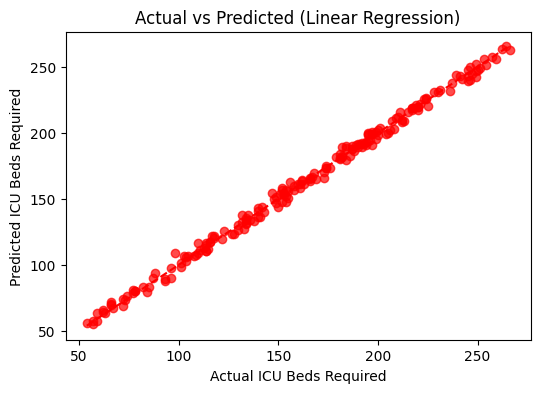

In [8]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_lr, alpha=0.7, color='Red')
plt.xlabel("Actual ICU Beds Required")
plt.ylabel("Predicted ICU Beds Required")
plt.title("Actual vs Predicted (Linear Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

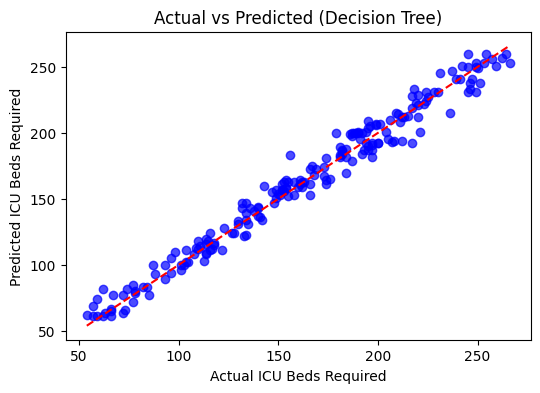

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_dt, alpha=0.7, color='blue')
plt.xlabel("Actual ICU Beds Required")
plt.ylabel("Predicted ICU Beds Required")
plt.title("Actual vs Predicted (Decision Tree)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

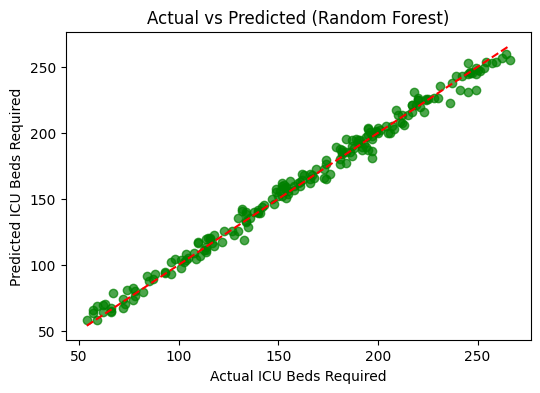

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='Green')
plt.xlabel("Actual ICU Beds Required")
plt.ylabel("Predicted ICU Beds Required")
plt.title("Actual vs Predicted (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

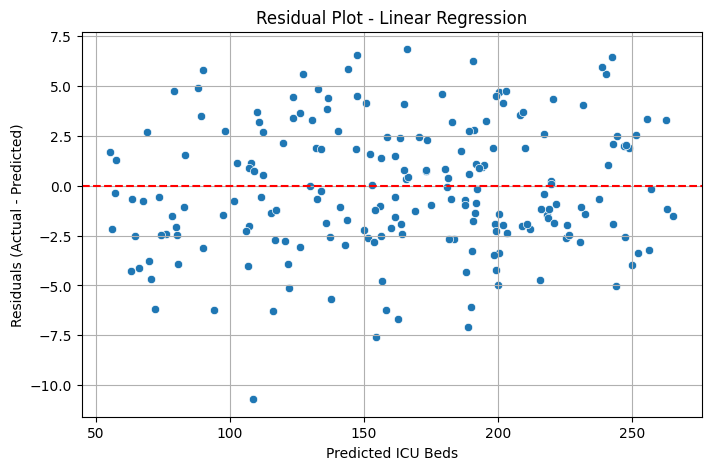

In [11]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_lr, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot - Linear Regression')
plt.xlabel('Predicted ICU Beds')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

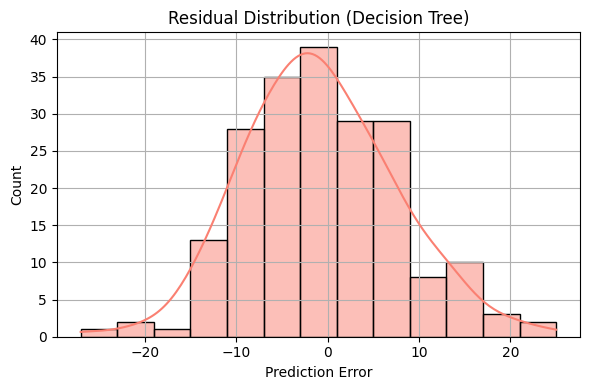

In [12]:
residuals = y_test - y_pred_dt
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color='salmon')
plt.title('Residual Distribution (Decision Tree)')
plt.xlabel('Prediction Error')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
import plotly.express as px

fig = px.scatter_3d(
    x=X_test.iloc[:, 0],
    y=X_test.iloc[:, 1],
    z=y_test,
    color=y_pred_rf,
    labels={'x': X_test.columns[0], 'y': X_test.columns[1], 'z': 'Actual ICU Beds'},
    title='3D Scatter: ICU Bed Prediction Color-Coded by Model Output'
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

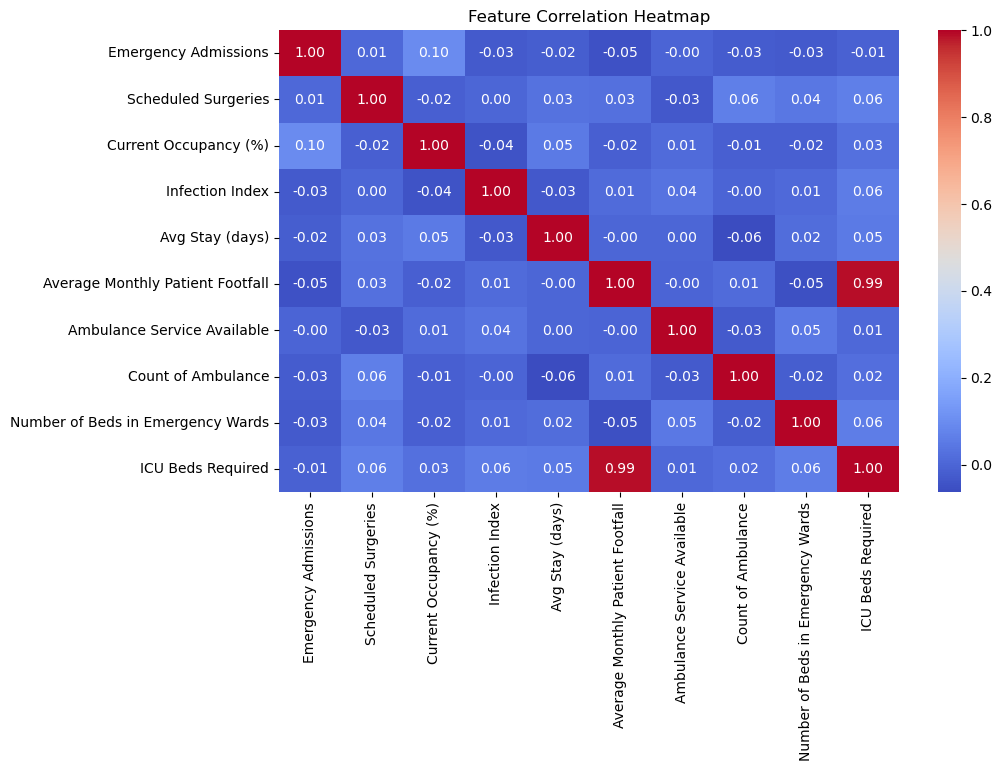

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]
rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf))
]

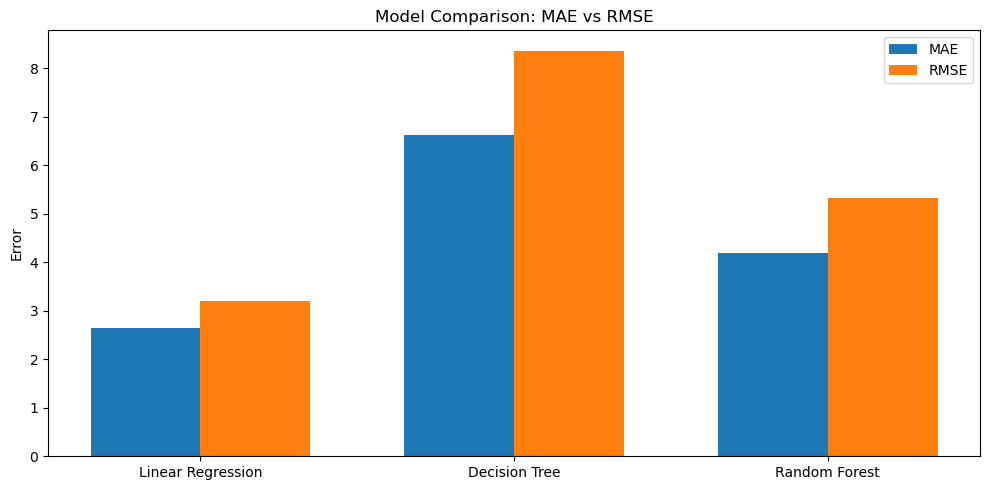

In [ ]:
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mae_scores, width, label='MAE')
plt.bar(x + width/2, rmse_scores, width, label='RMSE')
plt.xticks(x, model_names)
plt.ylabel("Error")
plt.title("Model Comparison: MAE vs RMSE")
plt.legend()
plt.tight_layout()
plt.show()